<a href="https://colab.research.google.com/github/azrilaazwar/RAMAN-SPATIOTEMPORAL-PCA-SVM-PIPELINE-4-PC-VERSION-/blob/main/Raman_Spatiotemporal_PCA_SVM_Pipeline_(4_PCA_Version).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
--- 10-FOLD CROSS-VALIDATION (SPHEROIDS 1-3) ---
Mean CV Accuracy: 89.18%
Standard Deviation: ±6.78%

--- BLIND TEST RESULTS FOR SPHEROID 4 ---
Total Test Spectra: 23
Independent Accuracy: 95.65%

Classification Report:
              precision    recall  f1-score   support

        Core       1.00      0.93      0.96        14
       Shell       0.90      1.00      0.95         9

    accuracy                           0.96        23
   macro avg       0.95      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23



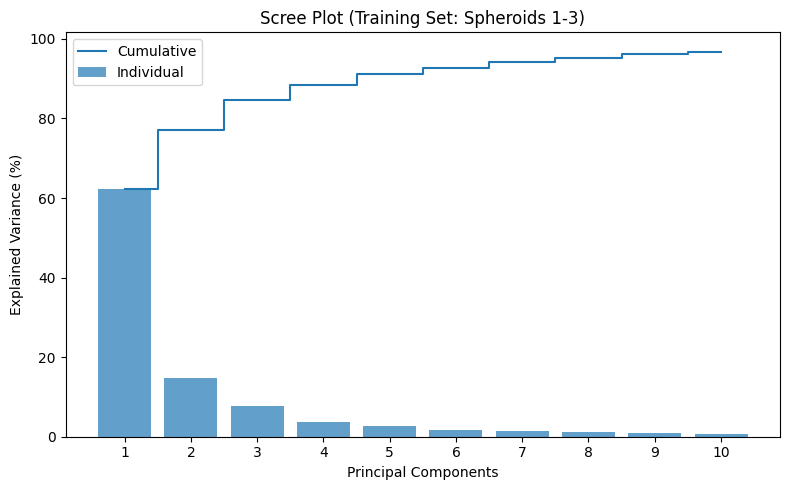

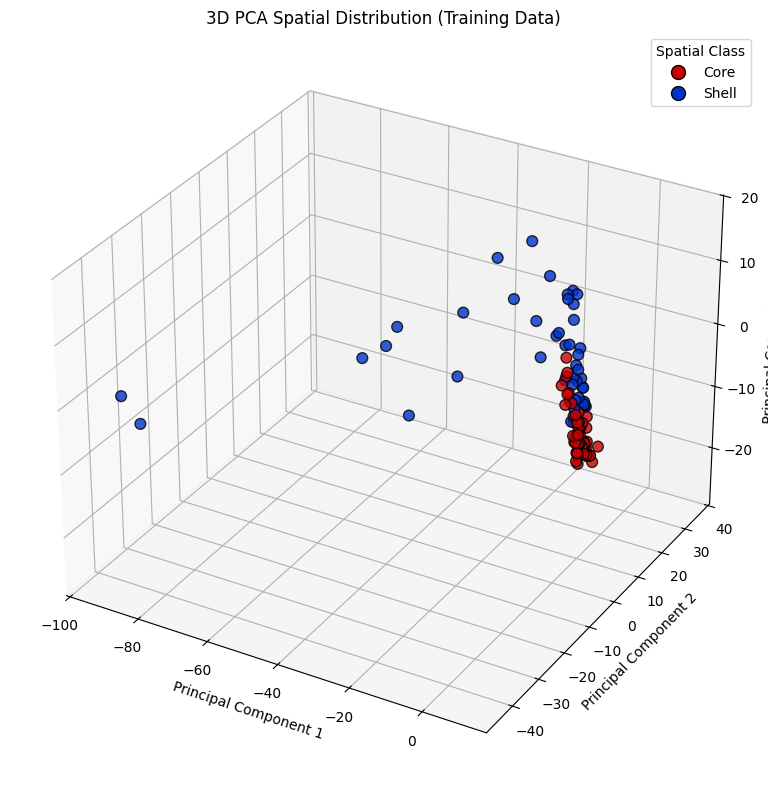

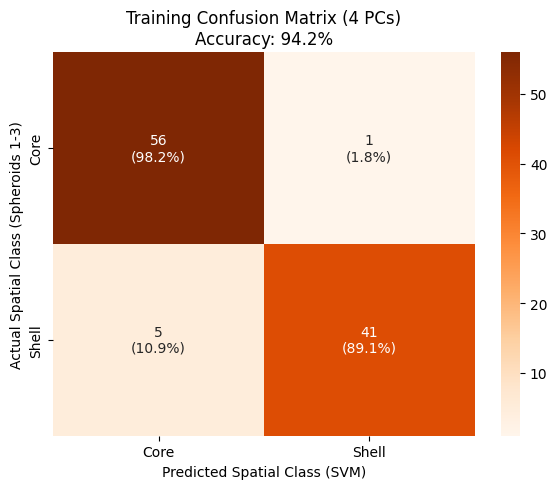

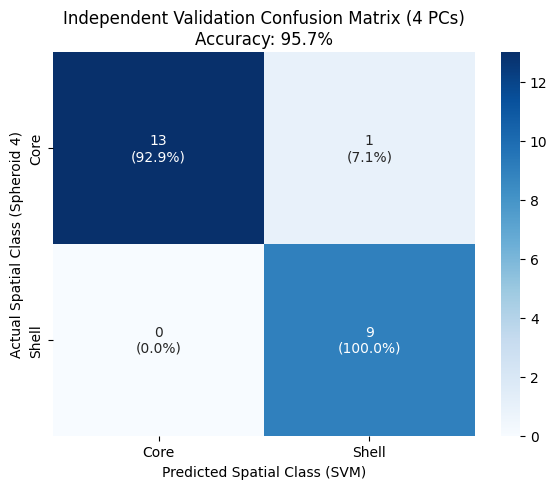

In [ ]:
# ==========================================
# RAMAN SPATIOTEMPORAL PCA-SVM PIPELINE (4-PC VERSION)
# ==========================================

# 0. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

# 1. Load Data from Google Drive
# Make sure your paths perfectly match your Colab Notebooks folder structure
file_path_core = '/content/drive/My Drive/Colab Notebooks/Core.xlsx'
file_path_shell = '/content/drive/My Drive/Colab Notebooks/Shell.xlsx'

df_core = pd.read_excel(file_path_core)
df_shell = pd.read_excel(file_path_shell)

# 2. Transpose and Label the Data
def prepare_data(df, spatial_label):
    # Set wavenumber as index and transpose so rows are spectra, columns are wavenumbers
    df_t = df.set_index('Wavenumber').T
    df_t.reset_index(inplace=True)
    df_t.rename(columns={'index': 'Sample_ID'}, inplace=True)

    # Extract Spheroid ID from the column header (e.g., 'S1_5' -> 'S1')
    df_t['Spheroid_ID'] = df_t['Sample_ID'].apply(lambda x: x.split('_')[0])
    df_t['Spatial_Class'] = spatial_label
    return df_t

core_data = prepare_data(df_core, 'Core')
shell_data = prepare_data(df_shell, 'Shell')

# Combine into one master dataset
df_master = pd.concat([core_data, shell_data], ignore_index=True)

# 3. Split into Train (S1, S2, S3) and Test (S4)
train_data = df_master[df_master['Spheroid_ID'].isin(['S1', 'S2', 'S3'])]
test_data = df_master[df_master['Spheroid_ID'] == 'S4']

# Separate features (X) and labels (y)
X_train_raw = train_data.drop(columns=['Sample_ID', 'Spheroid_ID', 'Spatial_Class'])
y_train = train_data['Spatial_Class']

X_test_raw = test_data.drop(columns=['Sample_ID', 'Spheroid_ID', 'Spatial_Class'])
y_test = test_data['Spatial_Class']

# Convert columns to string names to prevent sklearn feature name warnings
X_train_raw.columns = X_train_raw.columns.astype(str)
X_test_raw.columns = X_test_raw.columns.astype(str)

# Encode Labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# 4. Standardize the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 5. Principal Component Analysis (PCA)
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# ---> Extract PC1, PC2, PC3, and PC4 <---
X_train_pc_selected = X_train_pca[:, :4]
X_test_pc_selected = X_test_pca[:, :4]

# 6. SVM Model Setup & 10-Fold Cross-Validation (Using 4 PCs)
svm_model = SVC(kernel='linear', C=1.0, random_state=42)

# Perform 10-Fold Cross Validation on Training Data
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_model, X_train_pc_selected, y_train, cv=cv, scoring='accuracy')

print("--- 10-FOLD CROSS-VALIDATION (SPHEROIDS 1-3) ---")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: \u00b1{cv_scores.std() * 100:.2f}%\n")

# Train final model on all training data using the 4 selected PCs
svm_model.fit(X_train_pc_selected, y_train)

# 7. Blind Testing on Spheroid 4
y_pred = svm_model.predict(X_test_pc_selected)

print(f"--- BLIND TEST RESULTS FOR SPHEROID 4 ---")
print(f"Total Test Spectra: {len(y_test)}")
print(f"Independent Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


# ==========================================
# 8. VISUALIZATION FUNCTIONS
# ==========================================

# A. PCA Scree Plot
plt.figure(figsize=(8, 5))
explained_variance_ratio = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.bar(range(1, 11), explained_variance_ratio[:10], alpha=0.7, align='center', label='Individual')
plt.step(range(1, 11), cumulative_variance[:10], where='mid', label='Cumulative')
plt.ylabel('Explained Variance (%)')
plt.xlabel('Principal Components')
plt.title('Scree Plot (Training Set: Spheroids 1-3)')
plt.xticks(range(1, 11))
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('Scree_Plot_4PC.png', dpi=300)
plt.show()

# B. 3D PCA Scatter Plot (Visualizing PC1, PC2, PC3)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Define colors for the classes
colors = ['#cc0000' if label == 'Core' else '#0033cc' for label in y_train]

scatter = ax.scatter(X_train_pc_selected[:, 0],
                     X_train_pc_selected[:, 1],
                     X_train_pc_selected[:, 2],
                     c=colors, s=60, edgecolor='k', alpha=0.8)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA Spatial Distribution (Training Data)')

# Create a custom legend
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Core', markerfacecolor='#cc0000', markersize=10, markeredgecolor='k'),
                   Line2D([0], [0], marker='o', color='w', label='Shell', markerfacecolor='#0033cc', markersize=10, markeredgecolor='k')]
ax.legend(handles=legend_elements, title="Spatial Class", loc='best')

plt.tight_layout()
plt.savefig('3D_PCA_Plot.png', dpi=300)
plt.show()

# C. Confusion Matrix (Training Data - Spheroids 1-3)
# Predict on training data to generate the training CM
y_train_pred = svm_model.predict(X_train_pc_selected)
cm_train = confusion_matrix(y_train, y_train_pred, labels=['Core', 'Shell'])

plt.figure(figsize=(6, 5))
# Calculate percentages for annotation
cm_train_percent = cm_train.astype('float') / cm_train.sum(axis=1)[:, np.newaxis]
labels_train = np.array([f'{count}\n({perc:.1%})' for count, perc in zip(cm_train.flatten(), cm_train_percent.flatten())]).reshape(cm_train.shape)

sns.heatmap(cm_train, annot=labels_train, fmt='', cmap='Oranges',
            xticklabels=['Core', 'Shell'], yticklabels=['Core', 'Shell'])
plt.ylabel('Actual Spatial Class (Spheroids 1-3)')
plt.xlabel('Predicted Spatial Class (SVM)')
plt.title(f'Training Confusion Matrix (4 PCs)\nAccuracy: {accuracy_score(y_train, y_train_pred)*100:.1f}%')
plt.tight_layout()
plt.savefig('Confusion_Matrix_Train_4PC.png', dpi=300)
plt.show()

# D. Confusion Matrix (Blind Test - Spheroid 4)
cm_test = confusion_matrix(y_test, y_pred, labels=['Core', 'Shell'])
plt.figure(figsize=(6, 5))

# Calculate percentages for annotation
cm_test_percent = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]
labels_test = np.array([f'{count}\n({perc:.1%})' for count, perc in zip(cm_test.flatten(), cm_test_percent.flatten())]).reshape(cm_test.shape)

sns.heatmap(cm_test, annot=labels_test, fmt='', cmap='Blues',
            xticklabels=['Core', 'Shell'], yticklabels=['Core', 'Shell'])
plt.ylabel('Actual Spatial Class (Spheroid 4)')
plt.xlabel('Predicted Spatial Class (SVM)')
plt.title(f'Independent Validation Confusion Matrix (4 PCs)\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%')
plt.tight_layout()
plt.savefig('Confusion_Matrix_S4_4PC.png', dpi=300)
plt.show()